In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from dotenv import load_dotenv

load_dotenv()

from sqlalchemy import create_engine
import os

def connect_to_db():
    engine = create_engine(
        f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
        f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )
    return engine

engine = connect_to_db()

conn = engine.connect()

In [4]:
df = pd.read_sql("SELECT * FROM public.gold_model_dataset", engine)

df.head()

,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,stay_duration,...,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_booking_rate,destination_popularity,cluster_booking_rate,cluster_popularity,hotel_cluster,is_booking
0,14,0,0,9,1,solo,0,0,1,2,...,1.0,2.0,54.0,0.0,0.0697,3544,0.0341,264,88,0
1,38,0,0,2,1,group,0,0,2,4,...,1.0,4.0,123.0,0.0,0.1277,47,0.1001,1129,33,0
2,40,0,0,0,1,solo,0,0,1,1,...,1.0,1.0,1.0,0.0,0.1000,100,0.0655,885,76,0
3,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1317,896,13,0
4,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1143,1260,16,0


In [5]:
df["is_booking"].mean()

np.float64(0.08033497200188999)

In [6]:
def plot_categorical_vs_target(col):
    temp = df.groupby(col)["is_booking"].mean().sort_values(ascending=False)

    temp.plot(kind="bar", figsize=(10,4))
    plt.title(f"{col} vs Booking Rate")
    plt.ylabel("Booking Rate")
    plt.xticks(rotation=45)
    plt.show()

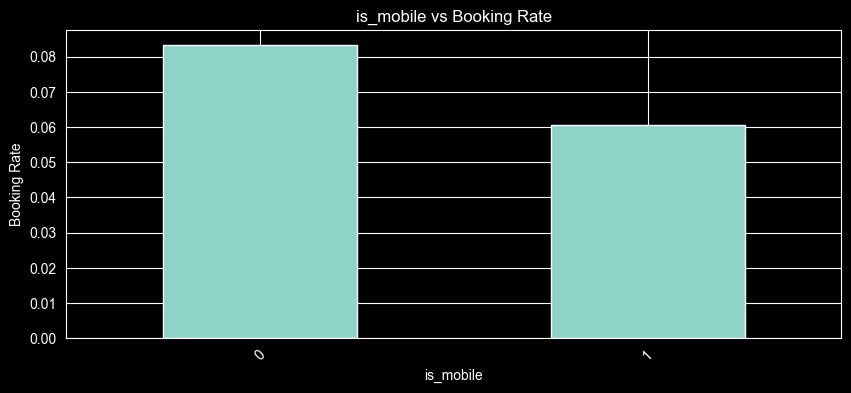

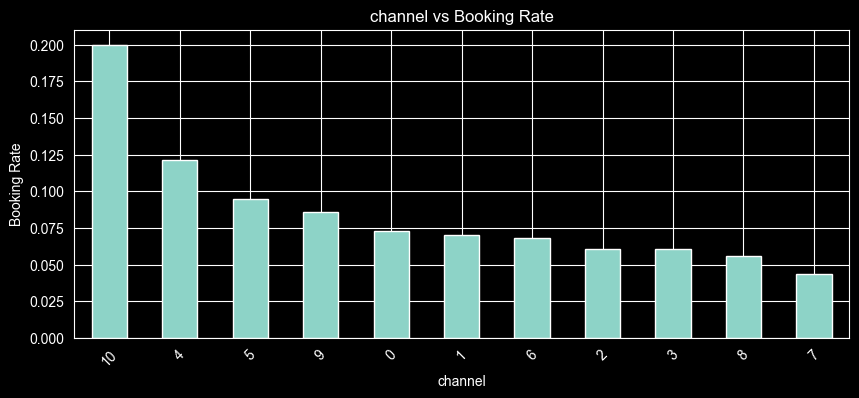

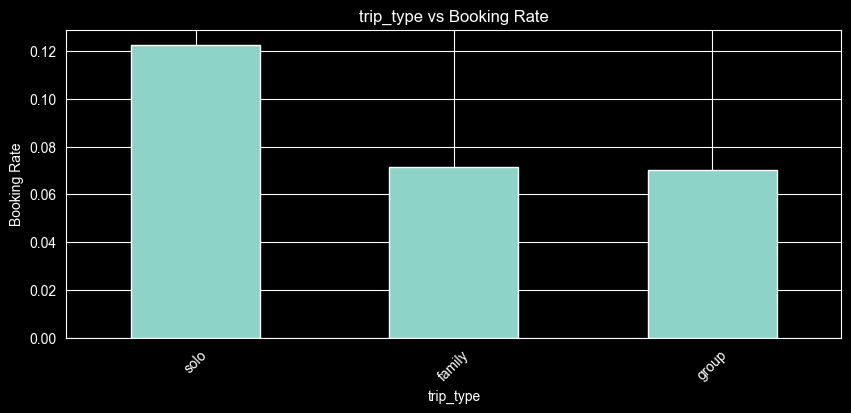

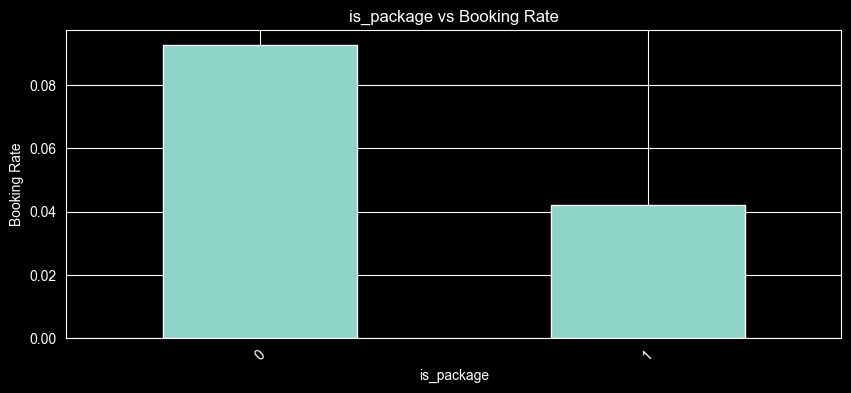

In [7]:
plot_categorical_vs_target("is_mobile")
plot_categorical_vs_target("channel")
plot_categorical_vs_target("trip_type")
plot_categorical_vs_target("is_package")

In [8]:
def plot_numeric_vs_target(col, bins=10):
    temp = df[[col, "is_booking"]].copy()
    temp["bin"] = pd.qcut(temp[col], q=bins, duplicates="drop")

    grouped = temp.groupby("bin")["is_booking"].mean()

    grouped.plot(kind="bar", figsize=(10,4))
    plt.title(f"{col} vs Booking Rate")
    plt.ylabel("Booking Rate")
    plt.xticks(rotation=45)
    plt.show()

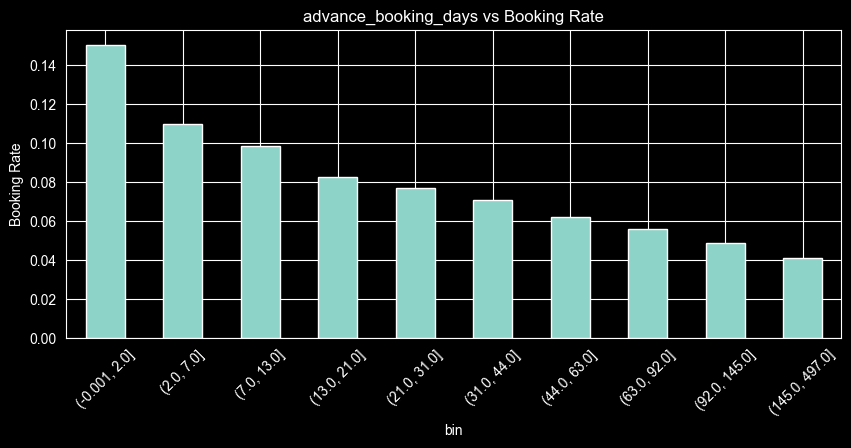

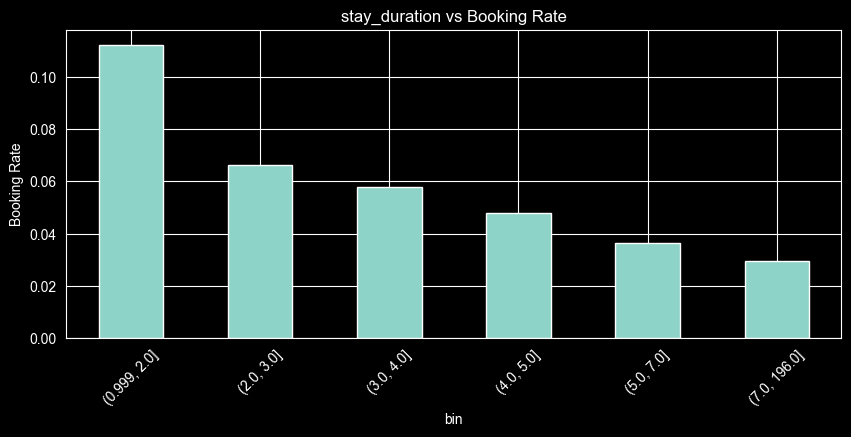

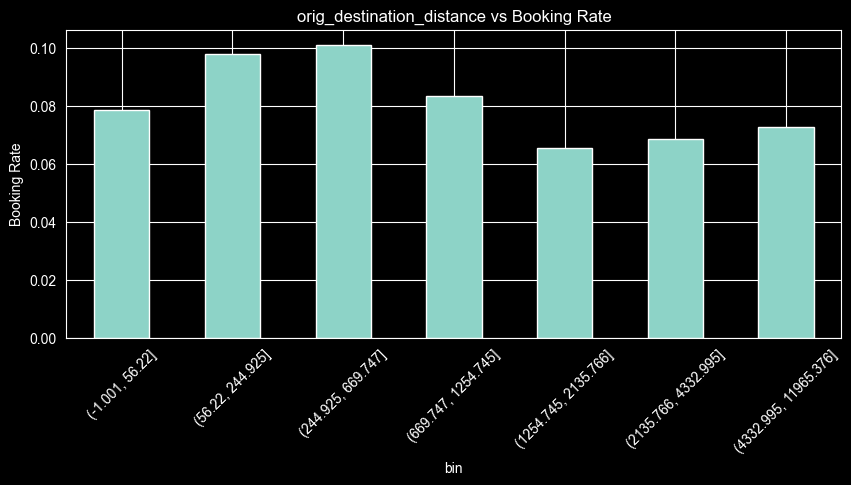

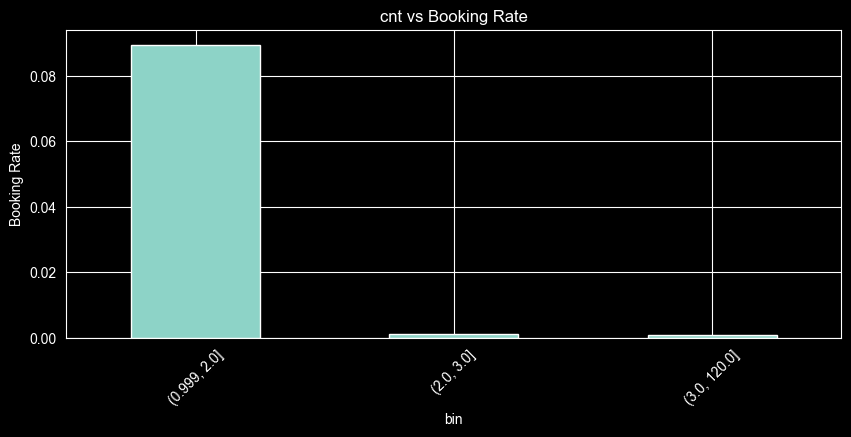

In [9]:
plot_numeric_vs_target("advance_booking_days")
plot_numeric_vs_target("stay_duration")
plot_numeric_vs_target("orig_destination_distance")
plot_numeric_vs_target("cnt")

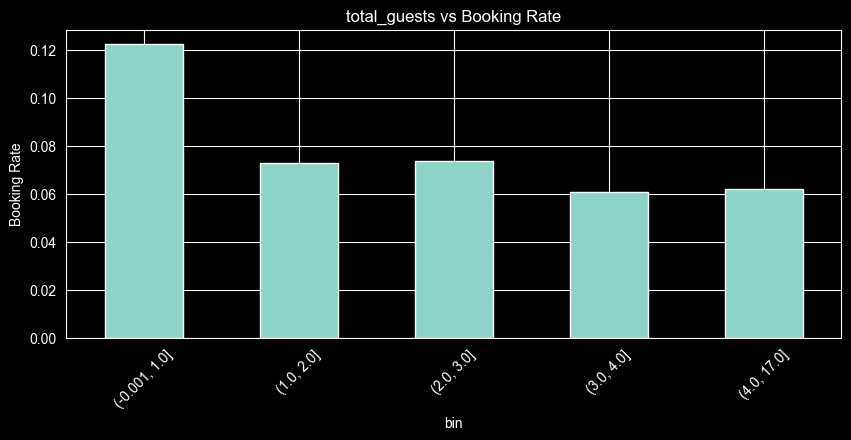

In [10]:
plot_numeric_vs_target("total_guests")

In [11]:
df.groupby("is_mobile")["is_booking"].mean()

is_mobile
0    0.083383
1    0.060551
Name: is_booking, dtype: float64

In [12]:
df.groupby("is_package")["is_booking"].mean()

is_package
0    0.092722
1    0.042240
Name: is_booking, dtype: float64

In [13]:
df.groupby("trip_type")["is_booking"].mean()

trip_type
family    0.071347
group     0.070252
solo      0.122673
Name: is_booking, dtype: float64

In [14]:
baseline = df["is_booking"].mean()
baseline

np.float64(0.08033497200188999)

In [15]:
def plot_with_lift(col):
    temp = df.groupby(col)["is_booking"].mean()
    lift = temp / baseline

    lift.plot(kind="bar", figsize=(10,4))
    plt.title(f"{col} - Lift vs Baseline")
    plt.ylabel("Lift")
    plt.xticks(rotation=45)
    plt.show()

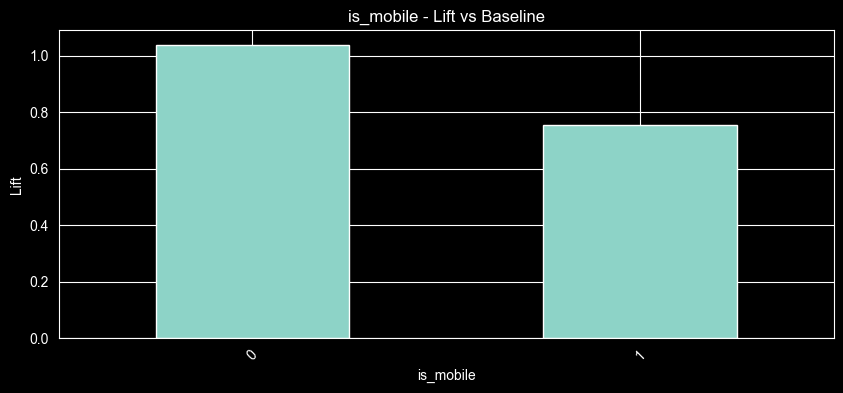

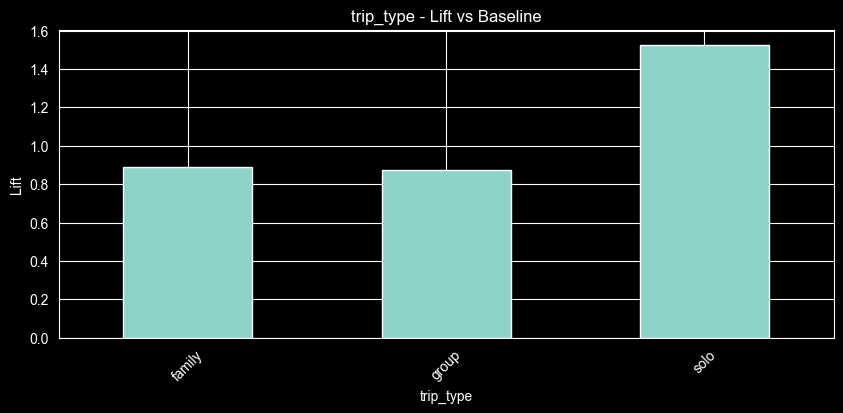

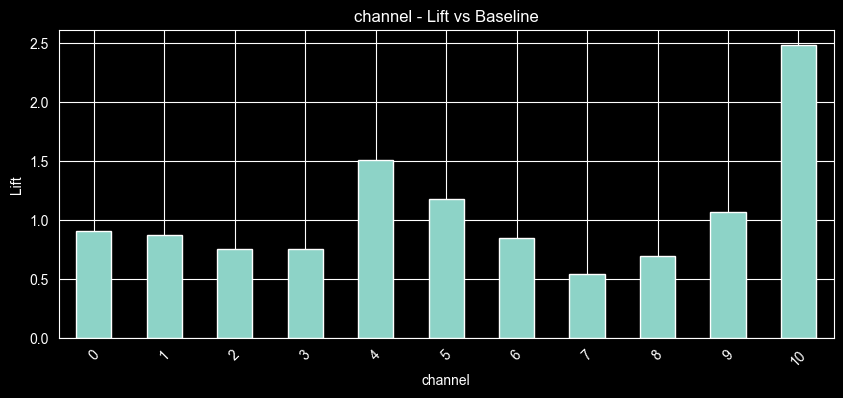

In [16]:
plot_with_lift("is_mobile")
plot_with_lift("trip_type")
plot_with_lift("channel")

In [17]:
def plot_numeric_full(col, bins=10):
    temp = df[[col, "is_booking"]].copy()
    temp["bin"] = pd.qcut(temp[col], q=bins, duplicates="drop")

    grouped = temp.groupby("bin").agg({
        "is_booking": "mean",
        col: "count"
    })

    fig, ax1 = plt.subplots(figsize=(10,4))

    grouped["is_booking"].plot(kind="bar", ax=ax1)
    ax1.set_ylabel("Booking Rate")

    ax2 = ax1.twinx()
    grouped[col].plot(color="red", ax=ax2)
    ax2.set_ylabel("Volume")

    plt.title(f"{col} vs Booking Rate + Volume")
    plt.xticks(rotation=45)
    plt.show()

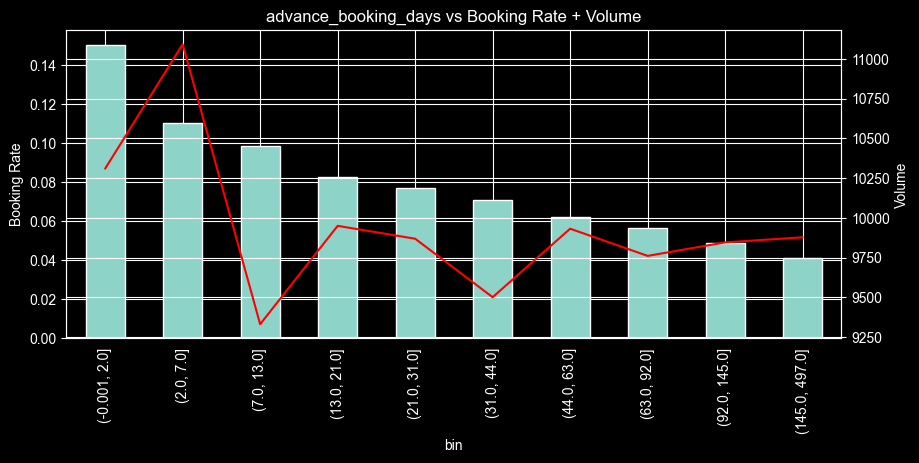

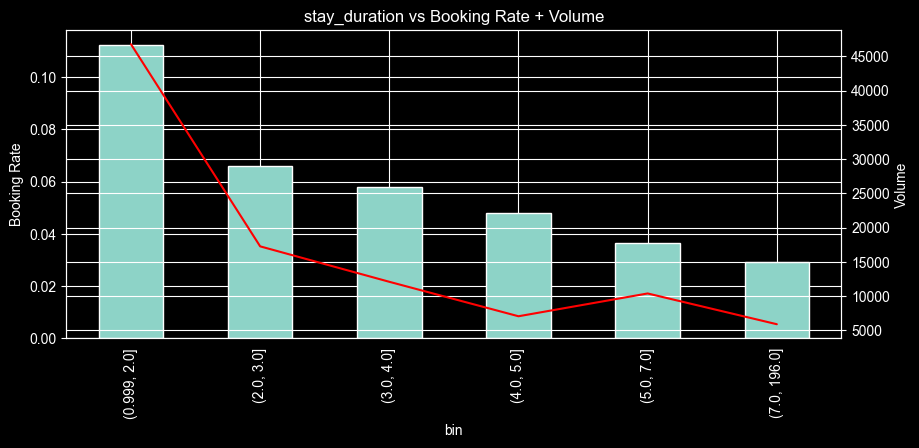

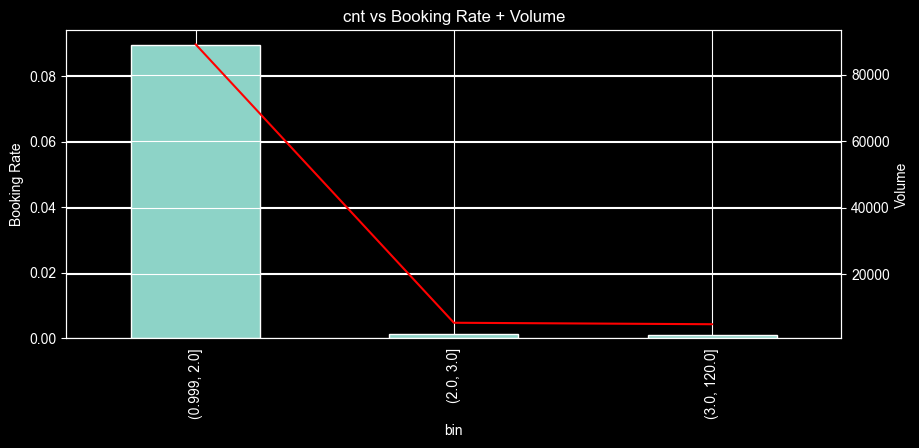

In [18]:
plot_numeric_full("advance_booking_days")
plot_numeric_full("stay_duration")
plot_numeric_full("cnt")

In [19]:
df.groupby(["is_mobile", "is_package"])["is_booking"].mean()

is_mobile  is_package
0          0             0.095241
           1             0.045297
1          0             0.074987
           1             0.026376
Name: is_booking, dtype: float64

In [20]:
top_channels = df["channel"].value_counts().head(10).index

df[df["channel"].isin(top_channels)] \
    .groupby("channel")["is_booking"].mean() \
    .sort_values(ascending=False)

channel
4    0.121226
5    0.094625
9    0.085766
0    0.072603
1    0.070029
6    0.067901
2    0.060769
3    0.060675
8    0.055762
7    0.043587
Name: is_booking, dtype: float64

In [21]:
conn.close()